In [19]:
import tensorflow as tf
from sklearn.model_selection import train_test_split
import pandas as pd
from sklearn.preprocessing import StandardScaler, OneHotEncoder
import numpy as np
from matplotlib import pyplot as plt
from tensorflow.keras.layers import Dropout
from imblearn.over_sampling import SMOTE
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.callbacks import EarlyStopping

In [20]:
# url address for the dataset
# url = "https://www.kaggle.com/datasets/fedesoriano/stroke-prediction-dataset"
# Load data
dataset_stroke = "C:/Users/maman/OneDrive/שולחן העבודה/dataset-stroke.csv"
data = pd.read_csv(dataset_stroke)

In [21]:
# get the columns headers
#data.columns

In [22]:
# Display the data
#data

In [23]:
# Count the number of sampeles that have stroke before cleaning (1)
#(data['stroke'] == 1).sum()

In [24]:
# Count the number of sampeles that did not have a stroke before cleaning (0)
#(data['stroke'] == 0).sum()

In [25]:
# Count the number of sampeles that  Nan before cleaning (0)
#data['bmi'].isna().sum()

In [26]:
# remove the id column
data = data.drop('id', axis=1)
# cleaning the data
fix_data = data[pd.notna(data['bmi'])]
# save new file after the cleaning
fix_file = "C:/Users/maman/OneDrive/שולחן העבודה/dataset-stroke-cleaned1.csv"
fix_data.to_csv(fix_file, index=False)

In [27]:
#fix_data

In [28]:
# Count the number of sampeles that have stroke after cleaning (1)
#(fix_data['stroke'] == 1).sum()

In [29]:
# Count the number of sampeles that did not have a stroke after cleaning (0)
#(fix_data['stroke'] == 0).sum()

In [30]:
# Count the number of sampeles that Nan after cleaning (0)
#fix_data['bmi'].isna().sum()

In [31]:
# Converting to boolean 
fix_data["ever_married"] = fix_data["ever_married"].map({"Yes": 1, "No": 0})
fix_data["Residence_type"] = fix_data["Residence_type"].map({"Rural": 1, "Urban": 0})

C:\Users\maman\AppData\Local\Temp\ipykernel_20304\2782824904.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  fix_data["ever_married"] = fix_data["ever_married"].map({"Yes": 1, "No": 0})
C:\Users\maman\AppData\Local\Temp\ipykernel_20304\2782824904.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  fix_data["Residence_type"] = fix_data["Residence_type"].map({"Rural": 1, "Urban": 0})


In [32]:
# להוסיף הערה ....
X = fix_data.drop('stroke', axis=1)
y = fix_data['stroke']

In [33]:
# Split the data into training, validation and test sets.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [34]:
# Division into types of variables
cat_cols = ['gender', 'work_type', 'smoking_status']
bin_cols = ['hypertension', 'heart_disease', 'Residence_type','ever_married']
num_cols = ['age', 'avg_glucose_level', 'bmi']

In [35]:
# Encode categorical features
ohe = OneHotEncoder(drop=None, sparse_output=False);
X_train_cat = ohe.fit_transform(X_train[cat_cols])
X_test_cat  = ohe.transform(X_test[cat_cols])

In [36]:
# Turn binary features into NumPy array for easy concatenation with other feature arrays
X_train_bin = X_train[bin_cols].to_numpy()
X_test_bin = X_test[bin_cols].to_numpy()

In [37]:
# Scale features
scaler = StandardScaler()
X_train_num = scaler.fit_transform(X_train[num_cols])
X_test_num  = scaler.transform(X_test[num_cols])

In [38]:
# Combine
X_train_ready = np.hstack([X_train_cat, X_train_bin, X_train_num])
X_test_ready  = np.hstack([X_test_cat, X_test_bin, X_test_num])

In [39]:
# Build neural network
model = tf.keras.Sequential([
     tf.keras.layers.Input(shape=(X_train_ready.shape[1],)),
    tf.keras.layers.Dense(16, activation='relu'),
    tf.keras.layers.Dense(16, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [40]:
# Train the model on the training set with validation
history = model.fit(
    X_train_ready, y_train,
    epochs=30, batch_size=32,
    validation_split=0.2,
    verbose=1
)

Epoch 1/30
99/99 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.6555 - loss: 0.5993 - val_accuracy: 0.9580 - val_loss: 0.2159
Epoch 2/30
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9554 - loss: 0.1898 - val_accuracy: 0.9580 - val_loss: 0.1559
Epoch 3/30
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9567 - loss: 0.1588 - val_accuracy: 0.9580 - val_loss: 0.1460
Epoch 4/30
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9584 - loss: 0.1459 - val_accuracy: 0.9580 - val_loss: 0.1418
Epoch 5/30
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9558 - loss: 0.1474 - val_accuracy: 0.9580 - val_loss: 0.1427
Epoch 6/30
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9630 - loss: 0.1331 - val_accuracy: 0.9580 - val_loss: 0.1405
Epoch 7/30
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9570 - loss: 0.1373 - val_accuracy: 0.9580 - val_loss: 0.1397
Epoch 8/30
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9590 - loss: 0.1332 - val_accuracy: 0.9580 - val_loss:

In [41]:
# Evaluate the trained model on the test dataset and display accuracy
loss, accuracy = model.evaluate(X_test_ready, y_test, verbose=0)
print(f"Test Accuracy: {accuracy:.2f}")

Test Accuracy: 0.96


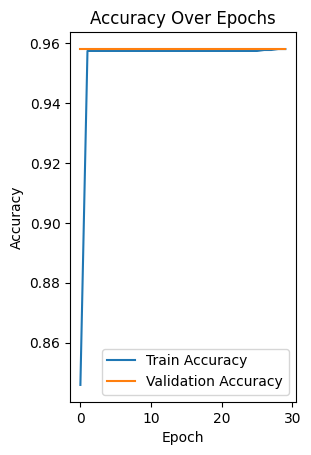

In [42]:
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

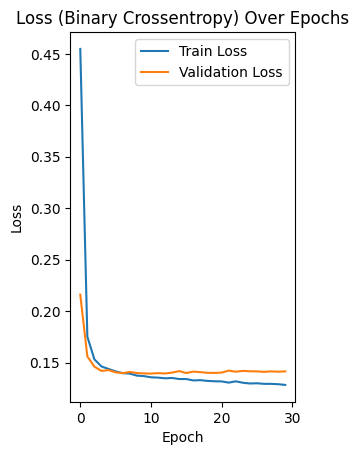

In [43]:
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss (Binary Crossentropy) Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [44]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
y_pred = (model.predict(X_test_ready, verbose=0) >= 0.5).astype(int)
# דוח סיווג
print("Classification Report:\n", classification_report(y_test, y_pred, digits=3, zero_division=0))
# מטריצת בלבול
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
# ROC AUC
y_proba = model.predict(X_test_ready, verbose=0).ravel()
print("ROC AUC Score:", roc_auc_score(y_test, y_proba))

Classification Report:
               precision    recall  f1-score   support

           0      0.957     1.000     0.978       940
           1      0.000     0.000     0.000        42

    accuracy                          0.957       982
   macro avg      0.479     0.500     0.489       982
weighted avg      0.916     0.957     0.936       982

Confusion Matrix:
 [[940   0]
 [ 42   0]]
ROC AUC Score: 0.794630192502533
